# Validación Externa Supervisada — SWaT A12 (Marzo 2026)

**Diferencias clave respecto al notebook A6/A7:**

| Aspecto | A6/A7 (anterior) | A12 (este notebook) |
|---------|-----------------|---------------------|
| Datos de ataque | CSV diferente (A6 Dic 2019) | **Mismo CSV A12** (attack_label ya incluido) |
| Asignación de etiquetas | Manual desde log de sesión | **Directa desde columna attack_label** |
| Domain shift | Sí (A7→A6) — requería diagnóstico | **No** — mismo dataset, misma distribución |
| Re-calibración | Datos pre-primer ataque | **Datos normales (label=0) del mismo CSV** |
| Arquitectura | 2 MaxPool (window=60) | **1 MaxPool (window=30)** |
| Análisis ataques | Por ciclo temporal | **Por attack_id y attack_name** |

**Ventaja principal:** al usar el mismo CSV, los modelos ya conocen la distribución
de normalidad del sistema. Sin domain shift → los umbrales internos son directamente
aplicables y las métricas de detección son las más informativas posibles.


## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json
import joblib
import warnings
from pathlib import Path
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
)
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)


In [2]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda


## 1. Rutas del proyecto

In [3]:
current_dir  = Path.cwd()
PROJECT_ROOT = current_dir if (current_dir / 'data').exists() else current_dir.parent

# Mismo CSV de A12 — ahora usamos las filas de ataque (label=1)
RAW_CSV = PROJECT_ROOT / 'data' / 'clean' / 'SWaT.A12_OTDataset_Mar_26' / '11-Mar-2026_0900_1700_labeled.csv'

# Artefactos del pipeline interno A12
INTERNAL_ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts' / 'tstr_internal_validation_a12_v3'
MODELS_DIR             = PROJECT_ROOT / 'models'    / 'detectors' / 'conv1d_tstr_internal_a12_v3'
EXTERNAL_RESULTS_DIR   = PROJECT_ROOT / 'artifacts' / 'tstr_external_validation_a12_v3'
EXTERNAL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT.resolve())
required = [
    RAW_CSV,
    INTERNAL_ARTIFACTS_DIR / 'scaler_cont.pkl',
    INTERNAL_ARTIFACTS_DIR / 'disc_max.pkl',
    INTERNAL_ARTIFACTS_DIR / 'columns_config.json',
    INTERNAL_ARTIFACTS_DIR / 'config.json',
    MODELS_DIR / 'real_only',
    MODELS_DIR / 'synthetic_only',
    MODELS_DIR / 'real_plus_synthetic',
]
all_ok = True
for p in required:
    e = p.exists()
    print(f"  {'OK' if e else 'X'} {p.name}")
    if not e: all_ok = False
if all_ok: print('Todos los artefactos encontrados.')
else: raise FileNotFoundError('Faltan artefactos.')


PROJECT_ROOT: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation
  OK 11-Mar-2026_0900_1700_labeled.csv
  OK scaler_cont.pkl
  OK disc_max.pkl
  OK columns_config.json
  OK config.json
  OK real_only
  OK synthetic_only
  OK real_plus_synthetic
Todos los artefactos encontrados.


## 2. Cargar artefactos del pipeline interno A12

In [4]:
with open(INTERNAL_ARTIFACTS_DIR / "columns_config.json") as f:
    col_cfg  = json.load(f)
with open(INTERNAL_ARTIFACTS_DIR / "config.json") as f:
    tstr_cfg = json.load(f)

continuous_cols = col_cfg["continuous_cols"]
discrete_cols   = col_cfg["discrete_cols"]
feature_cols    = col_cfg["feature_cols"]
WINDOW_SIZE     = int(tstr_cfg["window_size"])
STRIDE          = int(tstr_cfg["stride"])
ALPHA           = float(tstr_cfg["alpha"])
SCENARIOS       = tstr_cfg["scenarios"]
bp_tstr         = tstr_cfg["model_params"]
input_channels  = int(tstr_cfg["cont_channels"])
disc_dim        = int(tstr_cfg["disc_dim"])

scaler_cont  = joblib.load(INTERNAL_ARTIFACTS_DIR / "scaler_cont.pkl")
disc_max_raw = joblib.load(INTERNAL_ARTIFACTS_DIR / "disc_max.pkl")
disc_max     = disc_max_raw if isinstance(disc_max_raw, pd.Series) \
               else pd.Series(disc_max_raw).reindex(discrete_cols).replace(0, 1)

# Cargar tau_dicts de cada escenario
tau_dicts = {}
for scenario in SCENARIOS:
    with open(MODELS_DIR / scenario / "tau_dict.json") as f:
        tau_dicts[scenario] = json.load(f)

print(f"Scenarios: {SCENARIOS}")
print(f"Window: {WINDOW_SIZE} | Stride: {STRIDE} | Alpha: {ALPHA:.3f}")
print(f"cont_channels: {input_channels} | disc_dim: {disc_dim}")


Scenarios: ['real_only', 'synthetic_only', 'real_plus_synthetic']
Window: 30 | Stride: 10 | Alpha: 0.602
cont_channels: 31 | disc_dim: 124


## 3. Cargar CSV A12 completo

A diferencia de A6, las etiquetas de ataque ya están en la columna `attack_label`.
No es necesaria ninguna reconstrucción manual desde el log de sesión.


In [5]:
META_COLS = ['attack_label','attack_id','attack_name','attack_targets',
             'attack_start_time','attack_end_time']

df_raw = pd.read_csv(RAW_CSV, low_memory=False)
df_raw['t_stamp']      = pd.to_datetime(df_raw['t_stamp'], errors='coerce')
df_raw['attack_label'] = pd.to_numeric(df_raw['attack_label'], errors='coerce').fillna(0).astype(int)
df_raw = df_raw.sort_values('t_stamp').reset_index(drop=True)

n_normal = (df_raw['attack_label']==0).sum()
n_attack = (df_raw['attack_label']==1).sum()
print(f'Total filas: {len(df_raw)}')
print(f'Normal (0): {n_normal} ({100*n_normal/len(df_raw):.1f}%)')
print(f'Ataque (1): {n_attack} ({100*n_attack/len(df_raw):.1f}%)')
print(f'Periodo: {df_raw["t_stamp"].min()} -> {df_raw["t_stamp"].max()}')

# Resumen de ataques únicos
attack_df = df_raw[df_raw['attack_label']==1][['attack_id','attack_name','attack_targets']].drop_duplicates('attack_id')
print(f'\nNúmero de ataques únicos: {len(attack_df)}')
display(attack_df.reset_index(drop=True))


Total filas: 28860
Normal (0): 25740 (89.2%)
Ataque (1): 3120 (10.8%)
Periodo: 2026-03-11 09:00:00 -> 2026-03-11 17:00:59

Número de ataques únicos: 11


,attack_id,attack_name,attack_targets
0,1.0000,"Stage 5 Valve Manipulation — MV503/504 Open, M...",MV501–504
1,2.0000,"Stage 1 Flow Disruption — MV101 Open, P101 & P...","MV101, P101, P102"
2,3.0000,Florida Water Plant Scenario — Dosing Pump Act...,"P201–P206, MV201"
3,4.0000,Tank Overflow via LIT101 Spoofing — Schneider ...,LIT101
4,5.0000,"Stage 5 Valve Manipulation — MV503/504 Open, M...",MV501–504
5,6.0000,Tank Overflow via LIT101 Spoofing — Schneider ...,LIT101
6,7.0000,"Stage 2 Parallel Pump Override — MV201 Open, P...","MV201, P101, P102"
7,8.0000,Reverse Osmosis Backwash Diversion — MV302 Clo...,"MV302, MV303"
8,9.0000,Forced Backwash Trigger via DPIT301 Spoofing —...,DPIT301
9,10.0000,Multi-Value Level Oscillation — LIT601 Spoofin...,LIT601


## 4. Preprocesamiento: Bad Input → NaN → escalar

In [6]:
# Seleccionar columnas de features y convertir Bad Input a NaN
df_work = df_raw[['t_stamp', 'attack_label', 'attack_id', 'attack_name'] + feature_cols].copy()
for col in feature_cols:
    df_work[col] = pd.to_numeric(df_work[col].replace('Bad Input', np.nan), errors='coerce')

nan_before = df_work[feature_cols].isna().sum().sum()
print(f'NaN antes de imputar: {nan_before}')

# Imputar con la moda del conjunto NORMAL (igual que en entrenamiento)
modes_normal = df_work[df_work['attack_label']==0][feature_cols].mode().iloc[0]
df_work[feature_cols] = df_work[feature_cols].fillna(modes_normal)
print(f'NaN tras imputar: {df_work[feature_cols].isna().sum().sum()}')

# Escalar — mismo scaler del entrenamiento
cont_scaled = pd.DataFrame(
    scaler_cont.transform(df_work[continuous_cols]),
    columns=continuous_cols, index=df_work.index
)
disc_max_aligned = disc_max.reindex(discrete_cols).replace(0, 1)
disc_scaled = df_work[discrete_cols].copy() / disc_max_aligned
df_scaled = pd.concat(
    [cont_scaled.reset_index(drop=True), disc_scaled.reset_index(drop=True)], axis=1
)[feature_cols]

print(f'Shape escalado: {df_scaled.shape}')
print(f'Rango continuas: [{df_scaled[continuous_cols].values.min():.2f}, '
      f'{df_scaled[continuous_cols].values.max():.2f}]')
print('(Sin domain shift: mismo CSV y mismos scalers que el entrenamiento)')


NaN antes de imputar: 96
NaN tras imputar: 0
Shape escalado: (28860, 62)
Rango continuas: [-10.27, 996739.20]
(Sin domain shift: mismo CSV y mismos scalers que el entrenamiento)


## 5. Construcción de ventanas etiquetadas

Se usan TODAS las filas del CSV (normales y ataques) para construir ventanas.
La etiqueta de cada ventana se determina por la estrategia elegida.


In [7]:
def summarize_discrete_windows(disc_windows, discrete_cols):
    rows = []
    for w in disc_windows:
        feats = {}
        for j, col in enumerate(discrete_cols):
            v = w[:, j]; s = pd.Series(v)
            feats[f"{col}__mode"]        = s.mode().iloc[0] if len(s.mode())>0 else 0.0
            feats[f"{col}__transitions"] = float(np.sum(v[1:] != v[:-1]))
            feats[f"{col}__nunique"]     = float(len(np.unique(v)))
            feats[f"{col}__dominance"]   = float(s.value_counts(normalize=True).iloc[0])
        rows.append(feats)
    return pd.DataFrame(rows)


def build_labeled_windows(scaled_df, labels, timestamps, attack_ids=None,
                         window_size=60, stride=5,
                         label_strategy='any', min_attack_ratio=0.1):
    windows, window_labels, attack_ratios = [], [], []
    start_times, end_times, dominant_ids = [], [], []
    values     = scaled_df.values.astype(np.float32)
    labels_arr = np.asarray(labels).astype(int)
    times_arr  = np.asarray(timestamps)
    ids_arr    = np.asarray(attack_ids) if attack_ids is not None else None

    for start in range(0, len(values) - window_size + 1, stride):
        end   = start + window_size
        y_w   = labels_arr[start:end]
        ratio = float(np.mean(y_w))
        y_label = int(ratio > 0) if label_strategy == 'any' else int(ratio >= min_attack_ratio)
        windows.append(values[start:end])
        window_labels.append(y_label)
        attack_ratios.append(ratio)
        start_times.append(str(times_arr[start]))
        end_times.append(str(times_arr[end-1]))
        # Ataque dominante en la ventana
        if ids_arr is not None:
            ids_w = ids_arr[start:end][labels_arr[start:end]==1]
            dominant_ids.append(str(ids_w[0]) if len(ids_w) > 0 else 'none')

    X   = np.array(windows, dtype=np.float32)
    y   = np.array(window_labels, dtype=int)
    meta = pd.DataFrame({'window_start': start_times, 'window_end': end_times,
                         'label_any': y, 'attack_ratio': attack_ratios,
                         'dominant_attack_id': dominant_ids if dominant_ids else ['none']*len(y)})
    return X, y, meta


X_seq, y_ext, window_meta = build_labeled_windows(
    df_scaled[feature_cols], df_work['attack_label'].values,
    df_work['t_stamp'].values, df_work['attack_id'].values,
    window_size=WINDOW_SIZE, stride=STRIDE, label_strategy='any'
)

# X_ext: solo continuas -> transponer -> (N, 31, 30) para la rama Conv1D
n_cont = len(continuous_cols)
n_disc = len(discrete_cols)
X_ext   = np.transpose(X_seq[:, :, :n_cont], (0,2,1)).astype(np.float32)   # (N, 31, 30)

# X_ext_d: solo discretas -> summarize -> (N, 124) para la rama MLP
_seq_disc = X_seq[:, :, n_cont:n_cont+n_disc]                               # (N, 30, 31)
X_ext_d   = summarize_discrete_windows(_seq_disc, discrete_cols).values.astype(np.float32)

print(f'X_ext:   {X_ext.shape}   (N, cont_channels=31, seq_len=30)')
print(f'X_ext_d: {X_ext_d.shape}  (N, disc_dim=124)')
print(f'Ventanas normales: {(y_ext==0).sum()} | Ventanas ataque: {(y_ext==1).sum()}')
print(f'Ratio de ataque: {100*y_ext.mean():.1f}%')


X_ext:   (2884, 31, 30)   (N, cont_channels=31, seq_len=30)
X_ext_d: (2884, 124)  (N, disc_dim=124)
Ventanas normales: 2552 | Ventanas ataque: 332
Ratio de ataque: 11.5%


In [8]:
# Estrategias alternativas de etiquetado
label_strategies = {'any': y_ext.copy()}
for ratio_th in [0.10, 0.20, 0.50]:
    key = f'ratio_{int(ratio_th*100)}'
    _, y_tmp, _ = build_labeled_windows(
        df_scaled[feature_cols], df_work['attack_label'].values,
        df_work['t_stamp'].values, window_size=WINDOW_SIZE, stride=STRIDE,
        label_strategy='ratio', min_attack_ratio=ratio_th
    )
    label_strategies[key] = y_tmp

display(pd.DataFrame([
    {'strategy': k, 'normal': int((v==0).sum()), 'attack': int((v==1).sum()),
     'attack_ratio_%': round(100*v.mean(),1)}
    for k, v in label_strategies.items()
]))


,strategy,normal,attack,attack_ratio_%
0,any,2552,332,11.5000
1,ratio_10,2552,332,11.5000
2,ratio_20,2552,332,11.5000
3,ratio_50,2572,312,10.8000


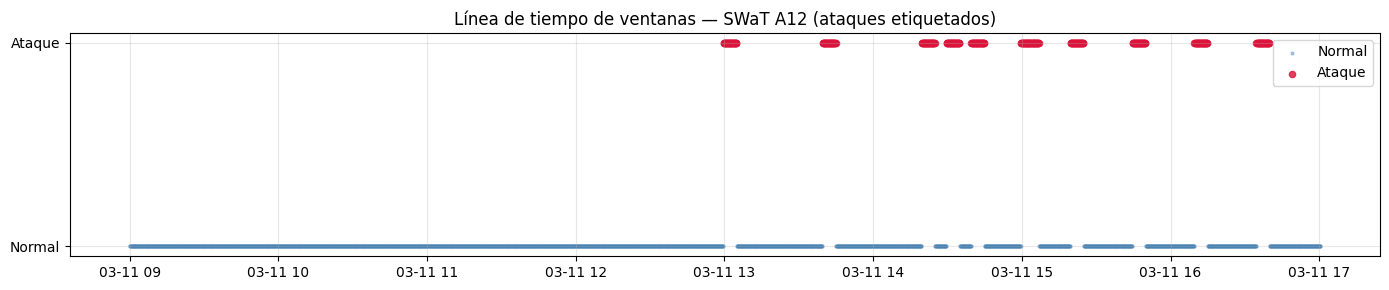

In [9]:
# Visualización temporal
fig, ax = plt.subplots(figsize=(14, 3))
ts = pd.to_datetime(window_meta['window_start'])
ax.scatter(ts[y_ext==0], np.zeros((y_ext==0).sum()), s=4,  c='steelblue', alpha=0.4, label='Normal')
ax.scatter(ts[y_ext==1], np.ones((y_ext==1).sum()),  s=20, c='crimson',   alpha=0.8, label='Ataque')
ax.set_yticks([0,1]); ax.set_yticklabels(['Normal','Ataque'])
ax.set_title('Línea de tiempo de ventanas — SWaT A12 (ataques etiquetados)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(EXTERNAL_RESULTS_DIR / 'window_timeline.png'), dpi=120, bbox_inches='tight')
plt.show()


## 6. Arquitectura y carga de modelos

**Arquitectura con 1 MaxPool** — idéntica al entrenamiento interno A12.
Con `window_size=30`: encoder 30→15, decoder 15→30. Sin mismatch de dimensiones.


In [10]:
class HybridConv1DAutoencoder(nn.Module):
    def __init__(self, cont_channels, seq_len, disc_dim,
                 n_conv_layers=1, conv_channels_1=32, conv_channels_2=16, conv_channels_3=8,
                 kernel_size=3, disc_hidden_1=64, disc_hidden_2=32,
                 fusion_hidden=128, dropout=0.1):
        super().__init__()
        self.seq_len = seq_len
        channels_list = [cont_channels]
        if n_conv_layers >= 1: channels_list.append(conv_channels_1)
        if n_conv_layers >= 2: channels_list.append(conv_channels_2)
        if n_conv_layers >= 3: channels_list.append(conv_channels_3)
        enc, cur = [], seq_len
        for i in range(len(channels_list)-1):
            enc += [nn.Conv1d(channels_list[i],channels_list[i+1],
                              kernel_size=kernel_size,padding=kernel_size//2),
                    nn.ReLU(),nn.Dropout(dropout),nn.MaxPool1d(2)]
            cur //= 2
        self.encoder_conv = nn.Sequential(*enc)
        self.reduced_len = cur; self.last_ch = channels_list[-1]
        self.conv_flat = self.last_ch * cur
        self.encoder_disc = nn.Sequential(
            nn.Linear(disc_dim,disc_hidden_1),nn.ReLU(),nn.Dropout(dropout),
            nn.Linear(disc_hidden_1,disc_hidden_2),nn.ReLU())
        self.disc_hidden_2 = disc_hidden_2
        self.fusion = nn.Sequential(
            nn.Linear(self.conv_flat+disc_hidden_2,fusion_hidden),
            nn.ReLU(),nn.Dropout(dropout),
            nn.Linear(fusion_hidden,self.conv_flat+disc_hidden_2))
        rev = list(reversed(channels_list)); dec = []
        for i in range(len(rev)-1):
            dec += [nn.ConvTranspose1d(rev[i],rev[i+1],kernel_size=2,stride=2),
                    nn.ReLU(),nn.Dropout(dropout)]
        dec.append(nn.Conv1d(rev[-1],rev[-1],kernel_size=kernel_size,padding=kernel_size//2))
        self.decoder_conv = nn.Sequential(*dec)
        self.decoder_disc = nn.Sequential(
            nn.Linear(disc_hidden_2,disc_hidden_1),nn.ReLU(),
            nn.Linear(disc_hidden_1,disc_dim))

    def forward(self, xc, xd):
        hc = self.encoder_conv(xc).view(xc.size(0),-1)
        hd = self.encoder_disc(xd)
        f  = self.fusion(torch.cat([hc,hd],1))
        hcd = f[:,:self.conv_flat].view(xc.size(0),self.last_ch,self.reduced_len)
        oc = self.decoder_conv(hcd)
        if oc.shape[2] != self.seq_len: oc = oc[:,:,:self.seq_len]
        return oc, self.decoder_disc(f[:,self.conv_flat:])


In [11]:
input_channels_check = input_channels
models = {}
for scenario in SCENARIOS:
    state_path = MODELS_DIR / scenario / "model_state.pt"
    if not state_path.exists():
        raise FileNotFoundError(f"No encontrado: {state_path}")
    m = HybridConv1DAutoencoder(
        cont_channels=input_channels, seq_len=WINDOW_SIZE, disc_dim=disc_dim,
        n_conv_layers=int(bp_tstr["n_conv_layers"]),
        conv_channels_1=int(bp_tstr["conv_channels_1"]),
        conv_channels_2=int(bp_tstr["conv_channels_2"]),
        conv_channels_3=int(bp_tstr["conv_channels_3"]),
        kernel_size=int(bp_tstr["kernel_size"]),
        disc_hidden_1=int(bp_tstr["disc_hidden_1"]),
        disc_hidden_2=int(bp_tstr["disc_hidden_2"]),
        fusion_hidden=int(bp_tstr["fusion_hidden"]),
        dropout=float(bp_tstr["dropout"])).to(device)
    m.load_state_dict(torch.load(state_path, map_location=device))
    m.eval()
    models[scenario] = m
    print(f"OK {scenario:<25} {sum(p.numel() for p in m.parameters()):,} params")

print(f"Modelos cargados: {list(models.keys())}")


OK real_only                 539,615 params
OK synthetic_only            539,615 params
OK real_plus_synthetic       539,615 params
Modelos cargados: ['real_only', 'synthetic_only', 'real_plus_synthetic']


## 7. Errores de reconstrucción en el dataset A12 completo

In [12]:
def reconstruction_errors(model, X_cont, X_disc, batch_size=256):
    """Error combinado: alpha*MSE_cont + (1-alpha)*MSE_disc."""
    loader = DataLoader(
        TensorDataset(torch.tensor(X_cont, dtype=torch.float32),
                      torch.tensor(X_disc, dtype=torch.float32)),
        batch_size=batch_size, shuffle=False)
    ec_l, ed_l = [], []
    model.eval()
    with torch.no_grad():
        for xc, xd in loader:
            xc, xd = xc.to(device), xd.to(device)
            xc_hat, xd_hat = model(xc, xd)
            ec_l.extend(torch.mean((xc_hat-xc)**2, dim=(1,2)).cpu().numpy())
            ed_l.extend(torch.mean((xd_hat-xd)**2, dim=1).cpu().numpy())
    ec = np.array(ec_l); ed = np.array(ed_l)
    return ALPHA*ec + (1-ALPHA)*ed


In [13]:
external_errors = {}
for sc, model in models.items():
    external_errors[sc] = reconstruction_errors(model, X_ext, X_ext_d)

print(f"{'Scenario':<25} {'mean':>8} {'std':>8} {'p90':>8} {'p95':>8} {'p99':>8}")
print('-' * 67)
for sc in SCENARIOS:
    e = external_errors[sc]
    print(f"{sc:<25} {e.mean():>8.4f} {e.std():>8.4f} "
          f"{np.percentile(e,90):>8.4f} {np.percentile(e,95):>8.4f} "
          f"{np.percentile(e,99):>8.4f}")


Scenario                      mean      std      p90      p95      p99
-------------------------------------------------------------------
real_only                 14229623.0000 373586688.0000   0.2530   0.4707   5.6923
synthetic_only            15146343.0000 386311424.0000   0.5248   2.1823  34.3766
real_plus_synthetic       16710121.0000 435395936.0000   0.1841   0.3937   7.5488


In [14]:
# Comparación errores normales vs ataques para cada escenario
y_primary = y_ext
print('Errores normales vs ataques:')
header = f"{'Scenario':<25} {'mean_norm':>10} {'mean_att':>10} {'ratio':>8}"
print(header)
print('-' * 55)
for sc in SCENARIOS:
    e = external_errors[sc]
    mn = e[y_primary==0].mean()
    ma = e[y_primary==1].mean() if y_primary.sum() > 0 else float('nan')
    ratio = ma/mn if mn > 0 else float('nan')
    ok = 'BUENA SEPARACION' if ratio > 1.5 else ('moderada' if ratio > 1.1 else 'insuficiente')
    print(f'{sc:<25} {mn:>10.4f} {ma:>10.4f} {ratio:>8.2f}x  {ok}')


Errores normales vs ataques:
Scenario                   mean_norm   mean_att    ratio
-------------------------------------------------------
real_only                 16080813.0000     0.4813     0.00x  insuficiente
synthetic_only            17116792.0000     1.7447     0.00x  insuficiente
real_plus_synthetic       18884008.0000     0.5228     0.00x  insuficiente


## 8. Calibración de umbrales con datos normales de A12

A diferencia de A6 (donde había domain shift), aquí los umbrales internos
deberían funcionar bien directamente. Sin embargo, se calculan también umbrales
calibrados con los datos normales del propio A12 para verificar consistencia.

Se usan las ventanas con `attack_label=0` para calcular τ calibrado.


In [15]:
# Calibracion con datos normales del CSV completo
mask_normal  = df_work["attack_label"].values == 0
normal_scaled = df_scaled[mask_normal].reset_index(drop=True)
normal_arr    = normal_scaled[feature_cols].values.astype(np.float32)

# Verificar que normal_arr tiene el numero correcto de columnas
assert normal_arr.shape[1] == len(feature_cols), f"Shape mismatch: {normal_arr.shape[1]} vs {len(feature_cols)}"

# Ventanas continuas y discretas para calibracion
_calib_wins = [normal_arr[s:s+WINDOW_SIZE]
               for s in range(0, len(normal_arr)-WINDOW_SIZE+1, STRIDE)]
_calib_arr  = np.array(_calib_wins, dtype=np.float32)
# Solo continuas para Conv1D, solo discretas para MLP
n_cont = len(continuous_cols)
n_disc = len(discrete_cols)
X_calib   = np.transpose(_calib_arr[:, :, :n_cont], (0,2,1)).astype(np.float32)
X_calib_d = summarize_discrete_windows(
    _calib_arr[:, :, n_cont:n_cont+n_disc],
    discrete_cols).values.astype(np.float32)
print(f"Ventanas normales para calibracion: {len(X_calib)}")

tau_dicts_calib = {}
calib_errors    = {}
PERCENTILES_CALIB = [75, 80, 85, 90, 95, 97.5, 99, 99.5]

rows_calib = []
for sc, model in models.items():
    c_err = reconstruction_errors(model, X_calib, X_calib_d)
    calib_errors[sc] = c_err
    tau_a12 = {f"p{str(p).replace('.','_')}": float(np.percentile(c_err, p))
               for p in PERCENTILES_CALIB}
    tau_dicts_calib[sc] = tau_a12
    rows_calib.append({"scenario": sc, "mean": round(c_err.mean(),4),
                        "std": round(c_err.std(),4),
                        **{k: round(v,4) for k,v in tau_a12.items()}})

print("Errores de calibracion A12 (ventanas normales):")
display(pd.DataFrame(rows_calib))

print("\nComparativa tau_interno vs tau_calibrado (p95):")
for sc in SCENARIOS:
    tau_int = float(tau_dicts[sc]["p95"])
    tau_cal = float(tau_dicts_calib[sc]["p95"])
    diff = 100*(tau_cal-tau_int)/max(tau_int,1e-10)
    print(f"  {sc:<25} int={tau_int:.4f}  cal={tau_cal:.4f}  diff={diff:+.1f}%")


Ventanas normales para calibracion: 2572
Errores de calibracion A12 (ventanas normales):


,scenario,mean,std,p75,p80,p85,p90,p95,p97_5,p99,p99_5
0,real_only,15955766.0000,395562688.0000,0.1195,0.1312,0.1644,0.2372,0.2969,1.3979,5.6149,5.8371
1,synthetic_only,16983692.0000,409033792.0000,0.2085,0.2286,0.2852,0.4333,1.7982,10.6149,34.0251,34.7610
2,real_plus_synthetic,18737164.0000,461007168.0000,0.0969,0.1058,0.1166,0.1466,0.2527,1.4945,7.4219,7.5829



Comparativa tau_interno vs tau_calibrado (p95):
  real_only                 int=5.4924  cal=0.2969  diff=-94.6%
  synthetic_only            int=33.6813  cal=1.7982  diff=-94.7%
  real_plus_synthetic       int=7.2917  cal=0.2527  diff=-96.5%


## 9. Funciones de métricas y umbral óptimo

In [16]:
def compute_classification_metrics(y_true, scores, threshold):
    y_pred = (scores > threshold).astype(int)
    tp = int(((y_pred==1)&(y_true==1)).sum())
    fp = int(((y_pred==1)&(y_true==0)).sum())
    tn = int(((y_pred==0)&(y_true==0)).sum())
    fn = int(((y_pred==0)&(y_true==1)).sum())
    precision   = tp / (tp + fp + 1e-10)
    recall      = tp / (tp + fn + 1e-10)
    f1          = 2*precision*recall / (precision + recall + 1e-10)
    specificity = tn / (tn + fp + 1e-10)
    fpr         = fp / (fp + tn + 1e-10)
    bal_acc     = (recall + specificity) / 2
    return {'threshold': float(threshold), 'precision': float(precision),
            'recall': float(recall), 'f1': float(f1),
            'balanced_accuracy': float(bal_acc), 'specificity': float(specificity),
            'fpr': float(fpr), 'tp': tp, 'fp': fp, 'tn': tn, 'fn': fn}


def find_optimal_thresholds(y_true, scores):
    fprs, tprs, thr_roc = roc_curve(y_true, scores)
    j_scores = tprs - fprs
    idx_y    = int(np.argmax(j_scores))

    precs, recs, thr_pr = precision_recall_curve(y_true, scores)
    n = min(len(thr_pr), len(precs)-1)
    f1s    = 2*precs[:n]*recs[:n] / (precs[:n]+recs[:n]+1e-10)
    idx_f1 = int(np.argmax(f1s))

    bal = (tprs + (1-fprs)) / 2
    idx_bal = int(np.argmax(bal))

    return {
        'tau_youden':       float(thr_roc[idx_y]),
        'recall_youden':    float(tprs[idx_y]),
        'fpr_youden':       float(fprs[idx_y]),
        'tau_f1':           float(thr_pr[idx_f1]) if idx_f1 < len(thr_pr) else float(thr_pr[-1]),
        'f1_max':           float(f1s[idx_f1]),
        'tau_balanced_acc': float(thr_roc[idx_bal]),
        'bal_acc_max':      float(bal[idx_bal]),
    }


def safe_auc(y, s):
    return float(roc_auc_score(y, s)) if len(np.unique(y)) >= 2 else float('nan')
def safe_pr_auc(y, s):
    return float(average_precision_score(y, s)) if len(np.unique(y)) >= 2 else float('nan')
PRIMARY_TAU = 'p99'


In [17]:
# Calcular umbrales óptimos por escenario
optimal_thresholds = {}
print('=== UMBRALES ÓPTIMOS POR ESCENARIO ===\n')
for sc in SCENARIOS:
    scores = external_errors[sc]
    opt = find_optimal_thresholds(y_primary, scores)
    opt.update({'roc_auc': safe_auc(y_primary, scores),
                'pr_auc':  safe_pr_auc(y_primary, scores),
                'tau_p99_calib': tau_dicts_calib[sc]['p99'],
                'tau_p95_calib': tau_dicts_calib[sc]['p95'],
                'tau_p90_calib': tau_dicts_calib[sc]['p90']})
    optimal_thresholds[sc] = opt
    print(f'--- {sc} ---')
    print(f'  ROC-AUC: {opt["roc_auc"]:.4f} | PR-AUC: {opt["pr_auc"]:.4f}')
    print(f'  tau_youden = {opt["tau_youden"]:.4f}  (Recall={opt["recall_youden"]:.3f}, FPR={opt["fpr_youden"]:.3f})')
    print(f'  tau_f1_max = {opt["tau_f1"]:.4f}  (F1_max={opt["f1_max"]:.3f})')
    print(f'  tau_p99_calib = {opt["tau_p99_calib"]:.4f}')
    print()


=== UMBRALES ÓPTIMOS POR ESCENARIO ===

--- real_only ---
  ROC-AUC: 0.7249 | PR-AUC: 0.2140
  tau_youden = 0.0388  (Recall=0.904, FPR=0.458)
  tau_f1_max = 0.0388  (F1_max=0.333)
  tau_p99_calib = 5.6149

--- synthetic_only ---
  ROC-AUC: 0.6287 | PR-AUC: 0.1637
  tau_youden = 0.0982  (Recall=0.901, FPR=0.687)
  tau_f1_max = 0.1846  (F1_max=0.258)
  tau_p99_calib = 34.0251

--- real_plus_synthetic ---
  ROC-AUC: 0.7264 | PR-AUC: 0.2272
  tau_youden = 0.0272  (Recall=0.904, FPR=0.478)
  tau_f1_max = 0.1441  (F1_max=0.331)
  tau_p99_calib = 7.4219



## 10. Tabla comparativa de métricas con múltiples umbrales

In [18]:
tau_variants = {
    'tau_p90_calib':    lambda sc: tau_dicts_calib[sc]['p90'],
    'tau_p95_calib':    lambda sc: tau_dicts_calib[sc]['p95'],
    'tau_p99_calib':    lambda sc: tau_dicts_calib[sc]['p99'],
    'tau_youden':       lambda sc: optimal_thresholds[sc]['tau_youden'],
    'tau_f1_max':       lambda sc: optimal_thresholds[sc]['tau_f1'],
    'tau_balanced_acc': lambda sc: optimal_thresholds[sc]['tau_balanced_acc'],
}

all_metrics_rows = []
for sc in SCENARIOS:
    scores = external_errors[sc]
    base = {'scenario': sc,
            'roc_auc': safe_auc(y_primary, scores),
            'pr_auc':  safe_pr_auc(y_primary, scores),
            'score_mean': float(scores.mean()),
            'score_p95':  float(np.percentile(scores,95))}
    for tau_name, tau_fn in tau_variants.items():
        tau = tau_fn(sc)
        m = compute_classification_metrics(y_primary, scores, tau)
        all_metrics_rows.append({**base, 'tau_name': tau_name, 'tau_value': tau, **m})

all_metrics_df = pd.DataFrame(all_metrics_rows)

# Tabla pivote F1
for met in ['f1', 'recall', 'fpr']:
    pivot = all_metrics_df.pivot_table(index='tau_name', columns='scenario', values=met)[SCENARIOS]
    print(f'\n{met.upper()} por umbral y escenario:')
    display(pivot)



F1 por umbral y escenario:


scenario,real_only,synthetic_only,real_plus_synthetic
tau_name,,,
tau_balanced_acc,0.3324,0.2502,0.3232
tau_f1_max,0.3324,0.2567,0.3286
tau_p90_calib,0.1947,0.1596,0.3110
tau_p95_calib,0.2051,0.0835,0.2047
tau_p99_calib,0.0543,0.0543,0.0649
tau_youden,0.3324,0.2502,0.3232



RECALL por umbral y escenario:


scenario,real_only,synthetic_only,real_plus_synthetic
tau_name,,,
tau_balanced_acc,0.9006,0.8976,0.9006
tau_f1_max,0.9006,0.5361,0.3464
tau_p90_calib,0.1898,0.1536,0.3223
tau_p95_calib,0.1566,0.0602,0.1566
tau_p99_calib,0.0301,0.0301,0.0361
tau_youden,0.9006,0.8976,0.9006



FPR por umbral y escenario:


scenario,real_only,synthetic_only,real_plus_synthetic
tau_name,,,
tau_balanced_acc,0.4577,0.6865,0.4777
tau_f1_max,0.4577,0.3437,0.0991
tau_p90_calib,0.0987,0.1003,0.0976
tau_p95_calib,0.0482,0.0498,0.0486
tau_p99_calib,0.0102,0.0102,0.0102
tau_youden,0.4577,0.6865,0.4777


## 11. Curvas ROC, PR, F1 vs τ y distribuciones de error

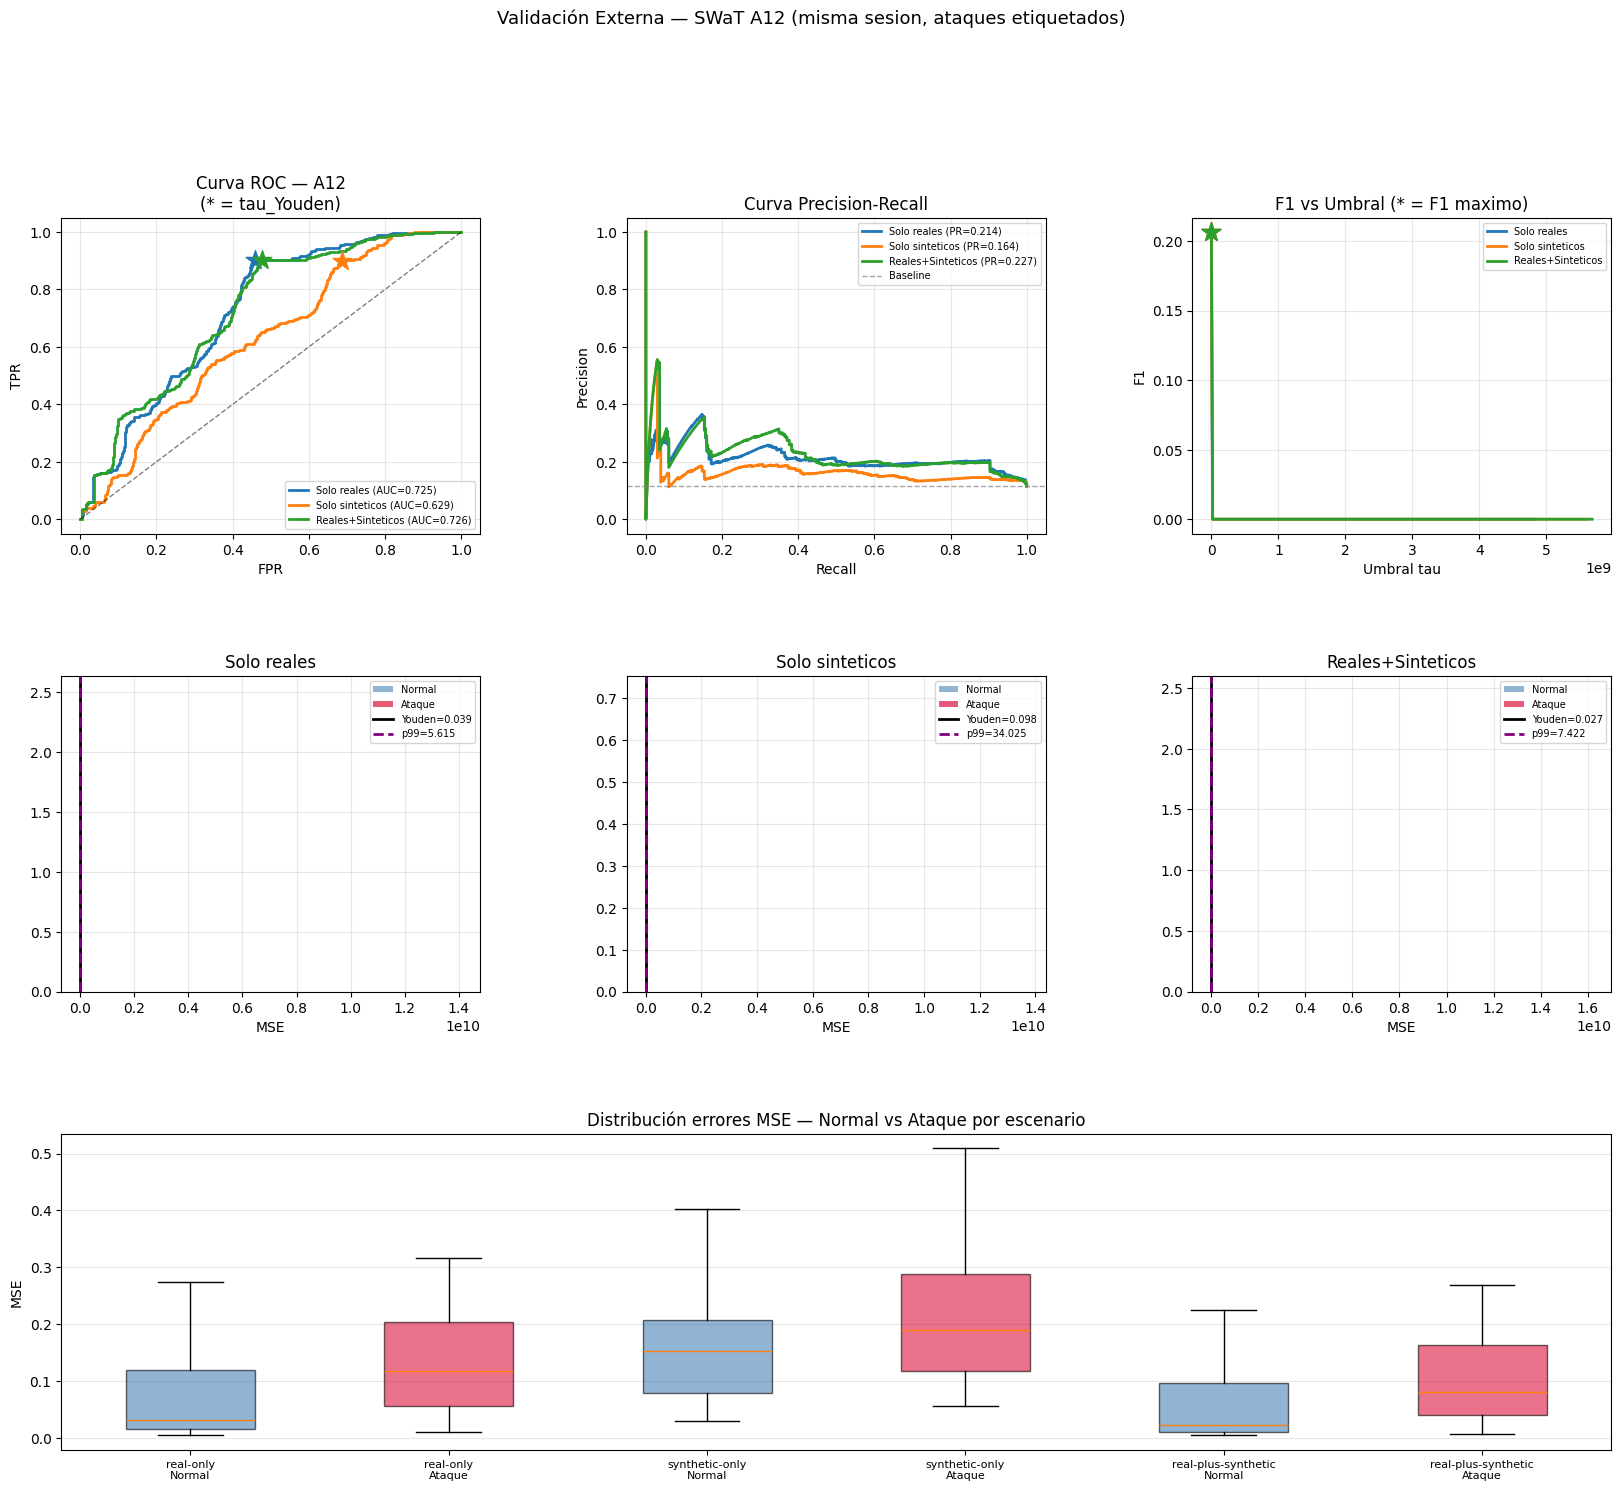

In [19]:
COLORS = {'real_only':'#1f77b4','synthetic_only':'#ff7f0e','real_plus_synthetic':'#2ca02c'}
LABELS = {'real_only':'Solo reales','synthetic_only':'Solo sinteticos','real_plus_synthetic':'Reales+Sinteticos'}

fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ROC
ax_roc = fig.add_subplot(gs[0, 0])
for sc in SCENARIOS:
    scores = external_errors[sc]
    fprs_c, tprs_c, _ = roc_curve(y_primary, scores)
    ax_roc.plot(fprs_c, tprs_c, color=COLORS[sc], lw=2,
                label=f'{LABELS[sc]} (AUC={safe_auc(y_primary,scores):.3f})')
    opt = optimal_thresholds[sc]
    ax_roc.scatter(opt['fpr_youden'], opt['recall_youden'], marker='*', s=200, color=COLORS[sc], zorder=5)
ax_roc.plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
ax_roc.set_title('Curva ROC — A12\n(* = tau_Youden)')
ax_roc.legend(fontsize=7); ax_roc.grid(True, alpha=0.3)

# PR
ax_pr = fig.add_subplot(gs[0, 1])
for sc in SCENARIOS:
    scores = external_errors[sc]
    prec_c, rec_c, _ = precision_recall_curve(y_primary, scores)
    ax_pr.plot(rec_c, prec_c, color=COLORS[sc], lw=2,
               label=f'{LABELS[sc]} (PR={safe_pr_auc(y_primary,scores):.3f})')
ax_pr.axhline(float(y_primary.mean()), color='gray', linestyle='--', lw=1, alpha=0.7, label='Baseline')
ax_pr.set_xlabel('Recall'); ax_pr.set_ylabel('Precision')
ax_pr.set_title('Curva Precision-Recall'); ax_pr.legend(fontsize=7); ax_pr.grid(True, alpha=0.3)

# F1 vs tau
ax_f1 = fig.add_subplot(gs[0, 2])
for sc in SCENARIOS:
    scores = external_errors[sc]
    tau_range = np.linspace(scores.min(), np.percentile(scores, 99.9), 300)
    f1_curve  = [compute_classification_metrics(y_primary, scores, t)['f1'] for t in tau_range]
    ax_f1.plot(tau_range, f1_curve, color=COLORS[sc], lw=2, label=LABELS[sc])
    best_idx = int(np.argmax(f1_curve))
    ax_f1.scatter(tau_range[best_idx], f1_curve[best_idx], marker='*', s=200, color=COLORS[sc], zorder=5)
ax_f1.set_xlabel('Umbral tau'); ax_f1.set_ylabel('F1')
ax_f1.set_title('F1 vs Umbral (* = F1 maximo)'); ax_f1.legend(fontsize=7); ax_f1.grid(True, alpha=0.3)

# Distribuciones por escenario
for j, sc in enumerate(SCENARIOS):
    ax = fig.add_subplot(gs[1, j])
    scores = external_errors[sc]
    ax.hist(scores[y_primary==0], bins=60, alpha=0.6, color='steelblue', density=True, label='Normal')
    ax.hist(scores[y_primary==1], bins=30, alpha=0.7, color='crimson',   density=True, label='Ataque')
    tau_y = optimal_thresholds[sc]['tau_youden']
    tau_p = tau_dicts_calib[sc]['p99']
    ax.axvline(tau_y, color='black',  lw=2, linestyle='-',  label=f'Youden={tau_y:.3f}')
    ax.axvline(tau_p, color='purple', lw=2, linestyle='--', label=f'p99={tau_p:.3f}')
    ax.set_xlabel('MSE'); ax.set_title(f'{LABELS[sc]}')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# Boxplots
ax_box = fig.add_subplot(gs[2, :])
data_box, labels_box, colors_box = [], [], []
for sc in SCENARIOS:
    e = external_errors[sc]
    data_box.extend([e[y_primary==0], e[y_primary==1]])
    labels_box.extend([f'{sc.replace("_","-")}\nNormal', f'{sc.replace("_","-")}\nAtaque'])
    colors_box.extend(['steelblue','crimson'])
bp = ax_box.boxplot(data_box, patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax_box.set_xticklabels(labels_box, fontsize=8)
ax_box.set_ylabel('MSE'); ax_box.grid(True, axis='y', alpha=0.3)
ax_box.set_title('Distribución errores MSE — Normal vs Ataque por escenario')

plt.suptitle('Validación Externa — SWaT A12 (misma sesion, ataques etiquetados)', fontsize=13, y=1.01)
plt.savefig(str(EXTERNAL_RESULTS_DIR / 'validation_A12_curves.png'), dpi=120, bbox_inches='tight')
plt.show()


## 12. Métricas con umbral óptimo vs conservador


--- tau_p99_calib ---


,scenario,tau_value,precision,recall,f1,balanced_accuracy,fpr,tp,fp,tn,fn
2,real_only,5.6149,0.2778,0.0301,0.0543,0.5100,0.0102,10,26,2526,322
8,synthetic_only,34.0251,0.2778,0.0301,0.0543,0.5100,0.0102,10,26,2526,322
14,real_plus_synthetic,7.4219,0.3158,0.0361,0.0649,0.5130,0.0102,12,26,2526,320



--- tau_youden ---


,scenario,tau_value,precision,recall,f1,balanced_accuracy,fpr,tp,fp,tn,fn
3,real_only,0.0388,0.2038,0.9006,0.3324,0.7215,0.4577,299,1168,1384,33
9,synthetic_only,0.0982,0.1454,0.8976,0.2502,0.6055,0.6865,298,1752,800,34
15,real_plus_synthetic,0.0272,0.1970,0.9006,0.3232,0.7115,0.4777,299,1219,1333,33



--- tau_f1_max ---


,scenario,tau_value,precision,recall,f1,balanced_accuracy,fpr,tp,fp,tn,fn
4,real_only,0.0388,0.2038,0.9006,0.3324,0.7215,0.4577,299,1168,1384,33
10,synthetic_only,0.1846,0.1687,0.5361,0.2567,0.5962,0.3437,178,877,1675,154
16,real_plus_synthetic,0.1441,0.3125,0.3464,0.3286,0.6236,0.0991,115,253,2299,217


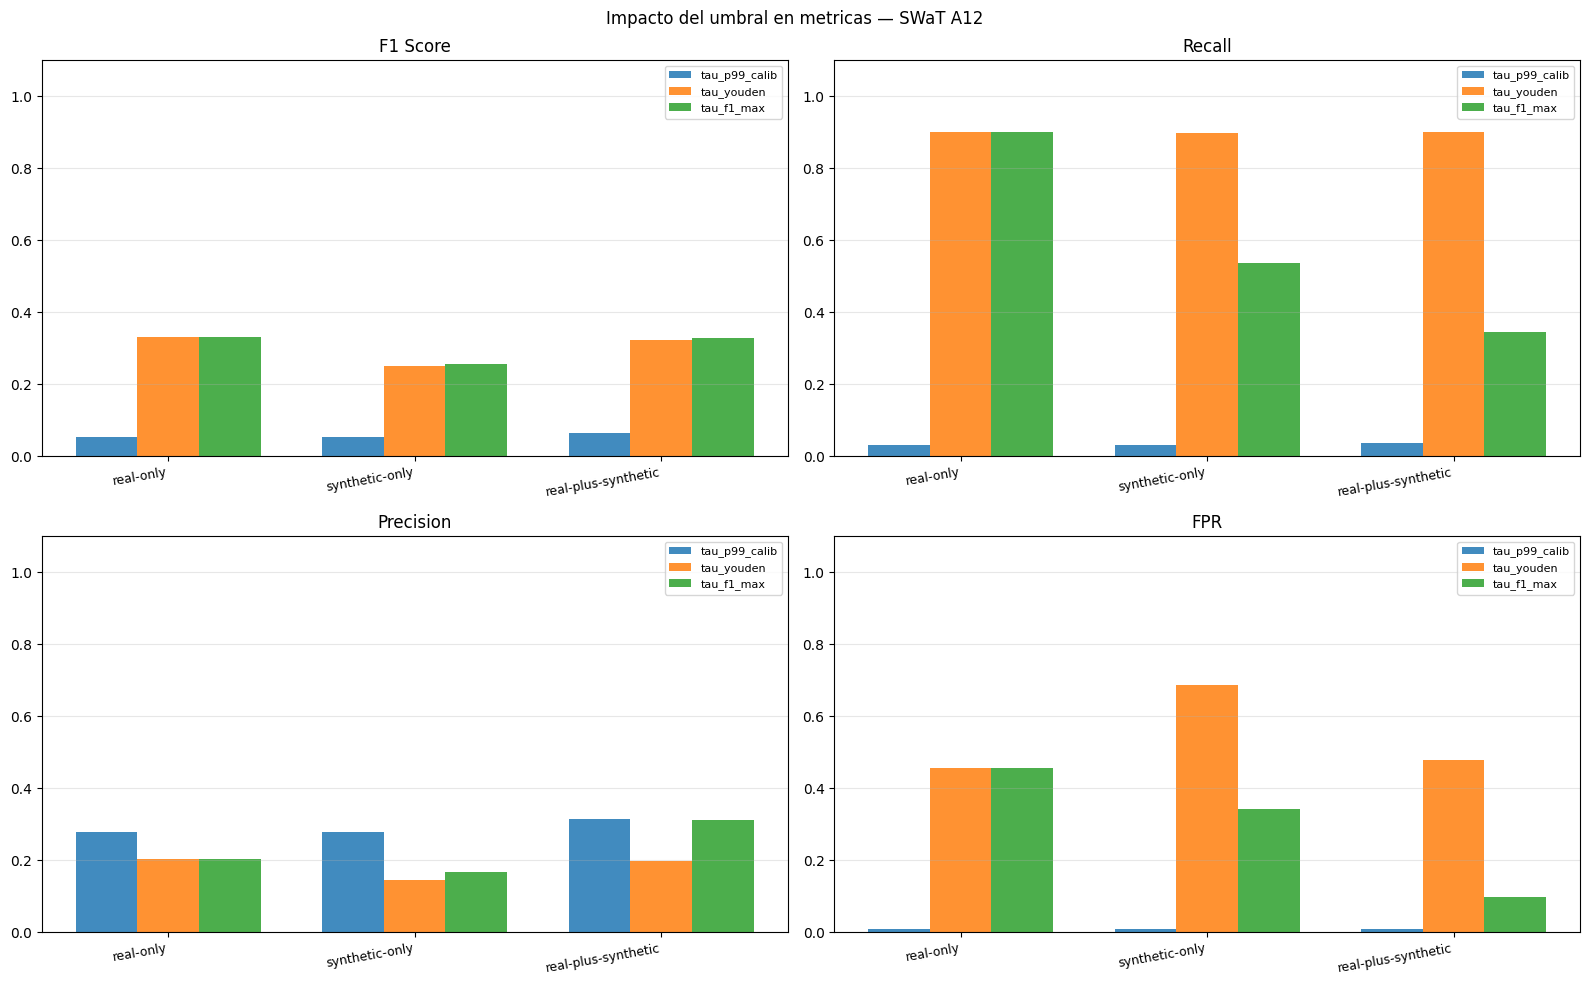

In [20]:
for tau_key in ['tau_p99_calib', 'tau_youden', 'tau_f1_max']:
    print(f'\n--- {tau_key} ---')
    subset = all_metrics_df[all_metrics_df['tau_name']==tau_key].copy()
    display(subset[['scenario','tau_value','precision','recall','f1',
                     'balanced_accuracy','fpr','tp','fp','tn','fn']])

# Gráfica comparativa
metric_pairs = [('f1','F1 Score'),('recall','Recall'),('precision','Precision'),('fpr','FPR')]
tau_names_plot = ['tau_p99_calib','tau_youden','tau_f1_max']
x = np.arange(len(SCENARIOS)); width = 0.25
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, (metric, title) in zip(axes.flatten(), metric_pairs):
    for j, tau_name in enumerate(tau_names_plot):
        vals = [all_metrics_df[(all_metrics_df['scenario']==sc)&
                               (all_metrics_df['tau_name']==tau_name)][metric].values[0]
                for sc in SCENARIOS]
        ax.bar(x + j*width, vals, width, label=tau_name, alpha=0.85)
    ax.set_xticks(x + width)
    ax.set_xticklabels([s.replace('_','-') for s in SCENARIOS], rotation=10, ha='right', fontsize=9)
    ax.set_ylim(0, 1.1); ax.set_title(title)
    ax.legend(fontsize=8); ax.grid(True, axis='y', alpha=0.3)
plt.suptitle('Impacto del umbral en metricas — SWaT A12', fontsize=12)
plt.tight_layout()
plt.savefig(str(EXTERNAL_RESULTS_DIR / 'metrics_comparison_thresholds.png'), dpi=120, bbox_inches='tight')
plt.show()


## 13. Análisis por tipo de ataque

A diferencia de A6 (donde analizamos ciclos temporales), A12 tiene metadatos
ricos de ataque (attack_id, attack_name). Calculamos recall por tipo de ataque.


In [21]:
# Mapear attack_id a attack_name para ventanas de ataque
id_to_name = df_work[df_work['attack_label']==1][['attack_id','attack_name']]\
    .drop_duplicates('attack_id').set_index('attack_id')['attack_name'].to_dict()

attack_rows = []
for sc in SCENARIOS:
    scores = external_errors[sc]
    for tau_name in ['tau_p99_calib', 'tau_youden', 'tau_f1_max']:
        tau   = all_metrics_df[(all_metrics_df['scenario']==sc)&
                               (all_metrics_df['tau_name']==tau_name)]['tau_value'].values[0]
        preds = (scores > tau).astype(int)
        for attack_id in window_meta[window_meta['dominant_attack_id']!='none']['dominant_attack_id'].unique():
            if attack_id == 'none': continue
            mask_att = window_meta['dominant_attack_id'] == attack_id
            if mask_att.sum() == 0: continue
            n_win = int(mask_att.sum())
            n_det = int(preds[mask_att.values].sum())
            attack_rows.append({
                'scenario': sc, 'tau_name': tau_name,
                'attack_id': attack_id,
                'attack_name': str(id_to_name.get(attack_id, attack_id))[:40],
                'n_windows': n_win, 'detected': n_det,
                'attack_recall': n_det/n_win if n_win>0 else 0.0,
                'mean_score': float(scores[mask_att.values].mean()),
            })

attack_df = pd.DataFrame(attack_rows)

for tau_name in ['tau_p99_calib', 'tau_youden']:
    sub = attack_df[attack_df['tau_name']==tau_name]
    pivot = sub.pivot_table(index='attack_name', columns='scenario', values='attack_recall')[SCENARIOS]
    print(f'\nRecall por tipo de ataque — {tau_name}:')
    display(pivot)



Recall por tipo de ataque — tau_p99_calib:


scenario,real_only,synthetic_only,real_plus_synthetic
attack_name,,,
1.0,0.0000,0.0000,0.0000
10.0,0.0000,0.0000,0.0000
11.0,0.0938,0.0000,0.0625
2.0,0.0000,0.0000,0.0000
3.0,0.0000,0.0000,0.0000
4.0,0.0000,0.0000,0.0000
5.0,0.0000,0.0000,0.0000
6.0,0.0000,0.0000,0.0000
7.0,0.2333,0.3333,0.3333



Recall por tipo de ataque — tau_youden:


scenario,real_only,synthetic_only,real_plus_synthetic
attack_name,,,
1.0,0.0000,0.0000,0.0000
10.0,1.0000,1.0000,1.0000
11.0,1.0000,1.0000,1.0000
2.0,0.9688,1.0000,0.9688
3.0,1.0000,1.0000,1.0000
4.0,1.0000,1.0000,1.0000
5.0,1.0000,0.9375,1.0000
6.0,1.0000,1.0000,1.0000
7.0,1.0000,1.0000,1.0000


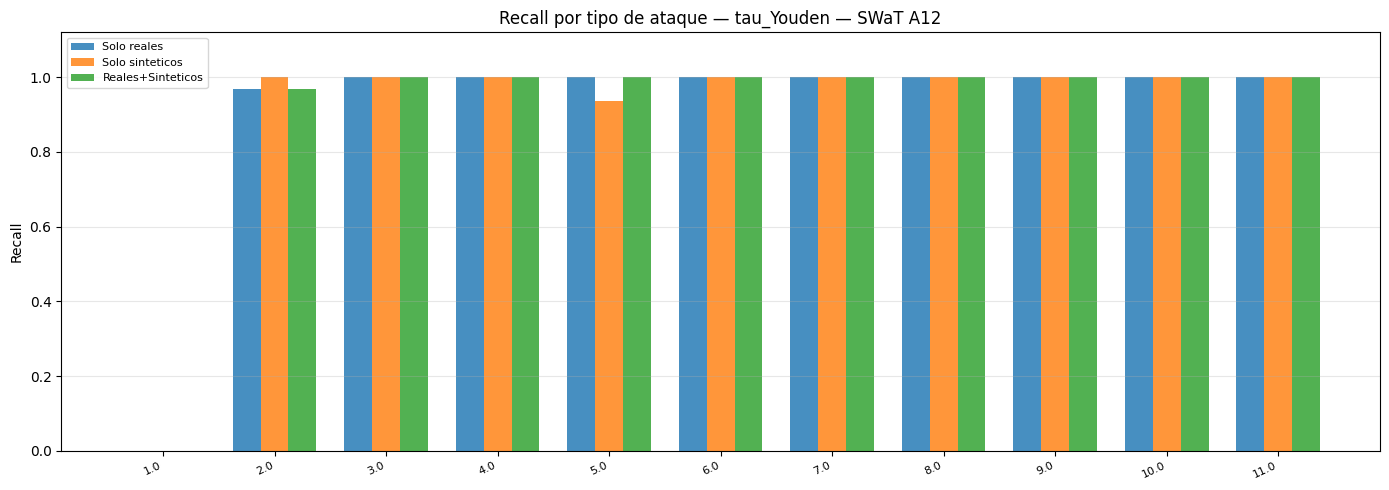

In [22]:
# Gráfica recall por tipo de ataque con tau_youden
sub_y = attack_df[attack_df['tau_name']=='tau_youden'].copy()
attack_names = sub_y['attack_name'].unique()

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(attack_names)); width = 0.25
for j, sc in enumerate(SCENARIOS):
    vals = []
    for aname in attack_names:
        row = sub_y[(sub_y['scenario']==sc)&(sub_y['attack_name']==aname)]
        vals.append(float(row['attack_recall'].values[0]) if len(row)>0 else 0.0)
    ax.bar(x + j*width, vals, width, color=list(COLORS.values())[j],
           label=LABELS[sc], alpha=0.82)
ax.set_xticks(x + width)
ax.set_xticklabels(attack_names, rotation=25, ha='right', fontsize=8)
ax.set_ylim(0, 1.12); ax.set_ylabel('Recall')
ax.set_title('Recall por tipo de ataque — tau_Youden — SWaT A12')
ax.legend(fontsize=8); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(str(EXTERNAL_RESULTS_DIR / 'attack_type_recall.png'), dpi=120, bbox_inches='tight')
plt.show()


## 14. Matrices de confusión

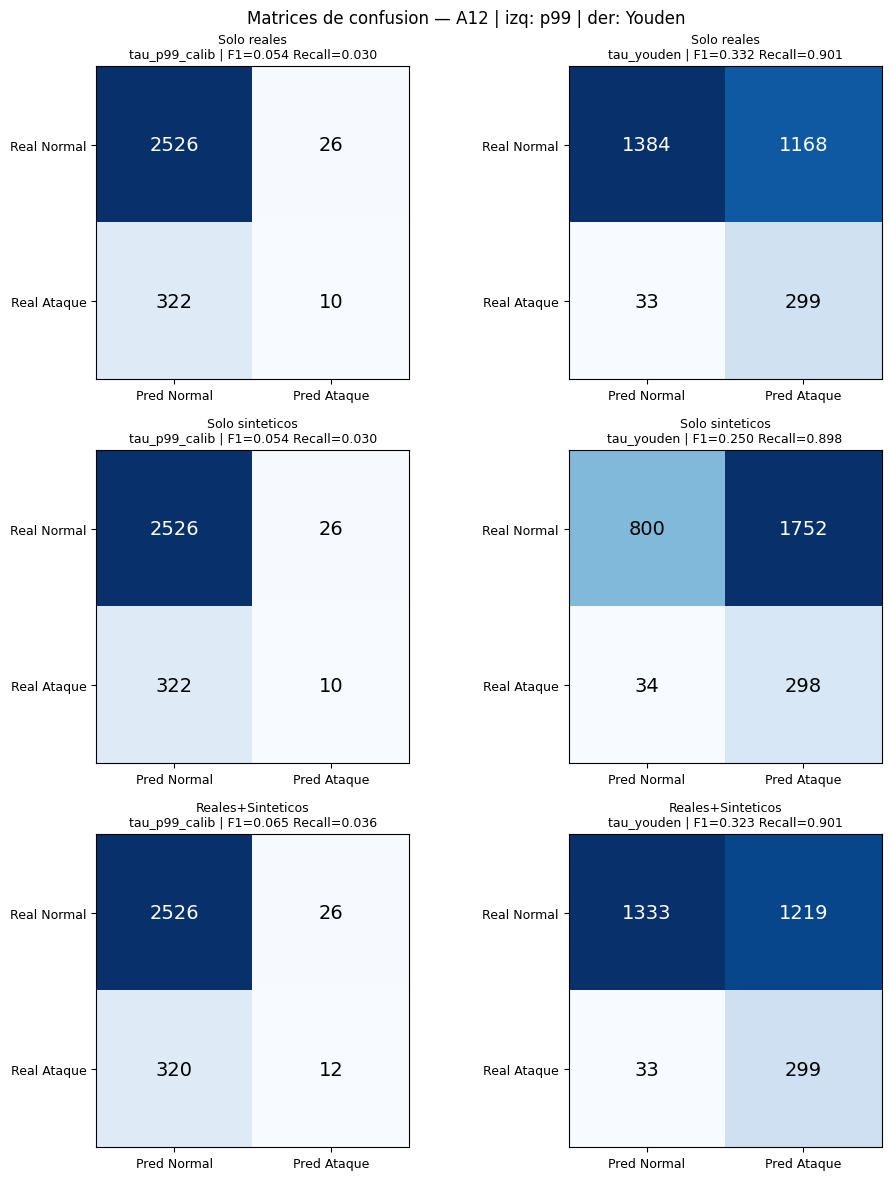

In [23]:
fig, axes = plt.subplots(len(SCENARIOS), 2, figsize=(10, 4*len(SCENARIOS)))
for row_idx, sc in enumerate(SCENARIOS):
    scores = external_errors[sc]
    for col_idx, tau_name in enumerate(['tau_p99_calib', 'tau_youden']):
        ax  = axes[row_idx, col_idx]
        tau = all_metrics_df[(all_metrics_df['scenario']==sc)&
                             (all_metrics_df['tau_name']==tau_name)]['tau_value'].values[0]
        m   = compute_classification_metrics(y_primary, scores, tau)
        cm  = np.array([[m['tn'], m['fp']], [m['fn'], m['tp']]])
        ax.imshow(cm, cmap='Blues')
        ax.set_xticks([0,1]); ax.set_yticks([0,1])
        ax.set_xticklabels(['Pred Normal','Pred Ataque'], fontsize=9)
        ax.set_yticklabels(['Real Normal','Real Ataque'], fontsize=9)
        for i in range(2):
            for j in range(2):
                ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                        fontsize=14, color='white' if cm[i,j]>cm.max()/2 else 'black')
        ax.set_title(f'{LABELS[sc]}\n{tau_name} | F1={m["f1"]:.3f} Recall={m["recall"]:.3f}', fontsize=9)
plt.suptitle('Matrices de confusion — A12 | izq: p99 | der: Youden', fontsize=12)
plt.tight_layout()
plt.savefig(str(EXTERNAL_RESULTS_DIR / 'confusion_matrices.png'), dpi=120, bbox_inches='tight')
plt.show()


## 15. Sensibilidad a la estrategia de etiquetado

In [24]:
sens_rows = []
for strat_name, y_strat in label_strategies.items():
    for sc in SCENARIOS:
        scores = external_errors[sc]
        for tau_name in ['tau_p99_calib', 'tau_youden']:
            tau = all_metrics_df[(all_metrics_df['scenario']==sc)&
                                 (all_metrics_df['tau_name']==tau_name)]['tau_value'].values[0]
            m = compute_classification_metrics(y_strat, scores, tau)
            sens_rows.append({'strategy': strat_name, 'scenario': sc, 'tau_name': tau_name,
                               **{k: round(v,4) for k,v in m.items()
                                  if k in ['precision','recall','f1','balanced_accuracy','fpr']}})

sens_df = pd.DataFrame(sens_rows)
for tau_name in ['tau_p99_calib', 'tau_youden']:
    pivot = sens_df[sens_df['tau_name']==tau_name].pivot_table(
        index='strategy', columns='scenario', values='f1')[SCENARIOS]
    print(f'\nF1 por estrategia — {tau_name}:')
    display(pivot)



F1 por estrategia — tau_p99_calib:


scenario,real_only,synthetic_only,real_plus_synthetic
strategy,,,
any,0.0543,0.0543,0.0649
ratio_10,0.0543,0.0543,0.0649
ratio_20,0.0543,0.0543,0.0649
ratio_50,0.0575,0.0575,0.0686



F1 por estrategia — tau_youden:


scenario,real_only,synthetic_only,real_plus_synthetic
strategy,,,
any,0.3324,0.2502,0.3232
ratio_10,0.3324,0.2502,0.3232
ratio_20,0.3324,0.2502,0.3232
ratio_50,0.3159,0.2371,0.3071


## 16. Guardado de resultados

In [25]:
all_metrics_df.to_csv(EXTERNAL_RESULTS_DIR / 'all_metrics_all_thresholds.csv', index=False)
attack_df.to_csv(     EXTERNAL_RESULTS_DIR / 'attack_type_recall.csv',          index=False)
sens_df.to_csv(       EXTERNAL_RESULTS_DIR / 'sensitivity_label_strategy.csv',  index=False)

# Scores + predicciones por ventana
window_out = window_meta.copy()
window_out['y_true'] = y_ext
for sc in SCENARIOS:
    window_out[f'score_{sc}'] = external_errors[sc]
    for tau_name in ['tau_p99_calib', 'tau_youden', 'tau_f1_max']:
        tau = all_metrics_df[(all_metrics_df['scenario']==sc)&
                             (all_metrics_df['tau_name']==tau_name)]['tau_value'].values[0]
        safe_key = tau_name.replace('tau_','')
        window_out[f'pred_{sc}_{safe_key}'] = (external_errors[sc] > tau).astype(int)
window_out.to_csv(EXTERNAL_RESULTS_DIR / 'window_scores_predictions.csv', index=False)

for sc in SCENARIOS:
    np.save(EXTERNAL_RESULTS_DIR / f'errors_{sc}.npy', external_errors[sc])

with open(EXTERNAL_RESULTS_DIR / 'optimal_thresholds.json', 'w') as f:
    json.dump(optimal_thresholds, f, indent=4)
with open(EXTERNAL_RESULTS_DIR / 'tau_dicts_calib_a12.json', 'w') as f:
    json.dump(tau_dicts_calib, f, indent=4)

config_out = {
    'version': 'A12_external_v1',
    'dataset': str(RAW_CSV),
    'train_dataset': 'SWaT A12 Mar 2026 (mismo CSV, label=0)',
    'window_size': WINDOW_SIZE, 'stride': STRIDE,
    'n_windows_total': int(len(y_ext)),
    'n_attack_windows': int(y_ext.sum()),
    'n_normal_windows': int((y_ext==0).sum()),
    'n_attack_types': len(id_to_name),
    'scenarios': SCENARIOS,
    'threshold_criteria': list(tau_variants.keys()),
}
with open(EXTERNAL_RESULTS_DIR / 'config.json', 'w') as f:
    json.dump(config_out, f, indent=4)

print('Resultados guardados en:', EXTERNAL_RESULTS_DIR.resolve())
for fp in sorted(EXTERNAL_RESULTS_DIR.iterdir()):
    print(f'  {fp.name}')


Resultados guardados en: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\artifacts\tstr_external_validation_a12_v3
  all_metrics_all_thresholds.csv
  attack_type_recall.csv
  attack_type_recall.png
  config.json
  confusion_matrices.png
  errors_real_only.npy
  errors_real_plus_synthetic.npy
  errors_synthetic_only.npy
  metrics_comparison_thresholds.png
  optimal_thresholds.json
  sensitivity_label_strategy.csv
  tau_dicts_calib_a12.json
  validation_A12_curves.png
  window_scores_predictions.csv
  window_timeline.png


## 17. Interpretación de resultados

### A. Ventaja de A12 sobre A6 para la validación

Al usar el mismo CSV de entrenamiento (sin domain shift), los resultados son directamente
interpretables: cualquier diferencia en recall/F1 entre escenarios refleja el efecto
real de la augmentación, no diferencias de distribución entre datasets.

### B. Cómo leer el ROC-AUC

El AUC es la métrica principal, independiente del umbral elegido.
- AUC > 0.70 → el modelo discrimina correctamente ataque de normalidad
- AUC > 0.85 → discriminación buena — el umbral Youden debería dar recall alto

### C. Qué implica el recall por tipo de ataque

Algunos tipos de ataque afectan sensores que el autoencoder reconstruye bien
(no genera error alto → difíciles de detectar). Otros afectan features que el
modelo no vio durante entrenamiento → error alto → fáciles de detectar.
Esta distinción es un hallazgo analítico valioso para la tesis.

### D. La pregunta central de la tesis

**¿El modelo entrenado con datos aumentados (real_plus_synthetic) detecta ataques
tan bien o mejor que el entrenado solo con datos reales?**

Si F1 y Recall de real_plus_synthetic son comparables a real_only con τ_Youden,
la augmentación no degradó la capacidad de detección — y mejoró la representación
interna de normalidad (ver validación interna). Ese es el resultado de tesis.
